## Data project

## Opgave 1.1

               ULLIG    KOMMUNEDK   TID  INDHOLD
0   Gini-koefficient  Hele landet  1987    22.07
1   Gini-koefficient  Hele landet  1988    22.06
2   Gini-koefficient  Hele landet  1989    21.93
3   Gini-koefficient  Hele landet  1990    22.16
4   Gini-koefficient  Hele landet  1991    21.99
5   Gini-koefficient  Hele landet  1992    22.34
6   Gini-koefficient  Hele landet  1993    22.79
7   Gini-koefficient  Hele landet  1994    22.50
8   Gini-koefficient  Hele landet  1995    22.41
9   Gini-koefficient  Hele landet  1996    22.83
10  Gini-koefficient  Hele landet  1997    23.47
11  Gini-koefficient  Hele landet  1998    23.81
12  Gini-koefficient  Hele landet  1999    23.83
13  Gini-koefficient  Hele landet  2000    24.38
14  Gini-koefficient  Hele landet  2001    24.40
15  Gini-koefficient  Hele landet  2002    24.03
16  Gini-koefficient  Hele landet  2003    24.14
17  Gini-koefficient  Hele landet  2004    24.68
18  Gini-koefficient  Hele landet  2005    25.66
19  Gini-koefficient

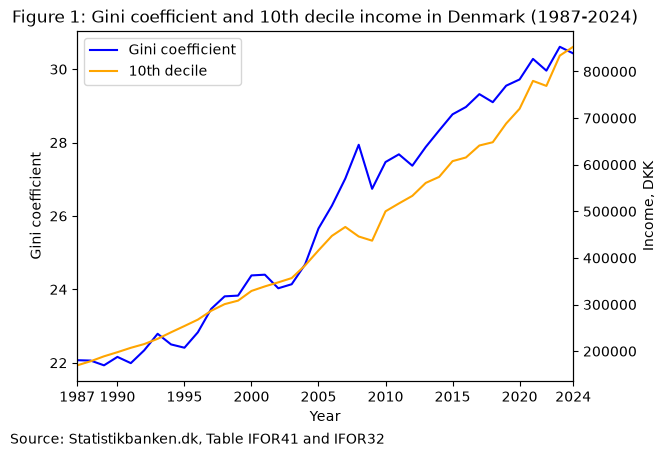

In [52]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO

# We import the data from Statistics Denmark's API. The data is about the Gini coefficient in Denmark, which measures income inequality.

url = "https://api.statbank.dk/v1/data"

query = {
    "table": "IFOR41",
   "format": "CSV",
   "variables": [
      {
         "code": "ULLIG",
         "placement": "Stub",
         "values": [
            "70"
         ]
      },
      {
         "code": "KOMMUNEDK",
         "placement": "Stub",
         "values": [
            "000"
         ]
      },
      {
         "code": "Tid",
         "placement": "Stub",
         "values": [
            "*"
         ]
      }
   ]
}

reponse = requests.post(url, json=query)

df = pd.read_csv(
    StringIO(reponse.text),
    sep=";",
    decimal=",",
)

url = "https://api.statbank.dk/v1/data"

query2 = {
    "table": "IFOR32",
   "format": "CSV",
   "variables": [
      {
         "code": "DECILGEN",
         "placement": "Stub",
         "values": [
            "10DC"
         ]
      },
      {
         "code": "KOMMUNEDK",
         "values": [
            "000"
         ]
      },
      {
         "code": "Tid",
         "values": [
            "*"
         ]
      }
   ]
}

response2 = requests.post(url, json=query2)

df2 = pd.read_csv(
    StringIO(response2.text),
    sep=";",
    decimal=","
)

print(df)
print(df2)

fig, ax1 = plt.subplots()

# Første y-akse: df
ax1.plot(
    df["TID"],
    df["INDHOLD"],
    label="Gini coefficient",
    color = "blue"
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Gini coefficient")


# Anden y-akse: df2
ax2 = ax1.twinx()

ax2.plot(
    df2["TID"],
    df2["INDHOLD"],
    label="10th decile",
    color = "orange"
)

ax2.set_ylabel("Income, DKK")


# Titel
plt.title("Figure 1: Gini coefficient and 10th decile income in Denmark (1987-2024)")


# X-akse
ax1.set_xlim(
    min(df["TID"].min(), df2["TID"].min()),
    max(df["TID"].max(), df2["TID"].max())
)

ax1.set_xticks([1987, 1990, 1995, 2000, 2005, 2010, 2015, 2020, 2024])



# Kilde
plt.subplots_adjust(bottom=0.15)

plt.figtext(
    0.02,
    0.02,
    "Source: Statistikbanken.dk, Table IFOR41 and IFOR32",
    ha="left"
)

# Vis både kurvelabels i legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")
plt.show()



ghg


## Opgave 1.2

Linear coefficients from minimize:
[21.04275355  0.26354959]

Quadratic coefficients from minimize:
[2.13041867e+01 2.19975902e-01 1.17767450e-03]

Linear coefficients:
Minimize: [21.04275355  0.26354959]
Polyfit:  [21.04275304  0.26354962]

Quadratic coefficients:
Minimize: [2.13041867e+01 2.19975902e-01 1.17767450e-03]
Polyfit:  [2.13042004e+01 2.19975061e-01 1.17769085e-03]

Predictions:
Linear prediction 2030: 32.38
Linear prediction 2040: 35.01
Quadratic prediction 2030: 32.94
Quadratic prediction 2040: 36.27


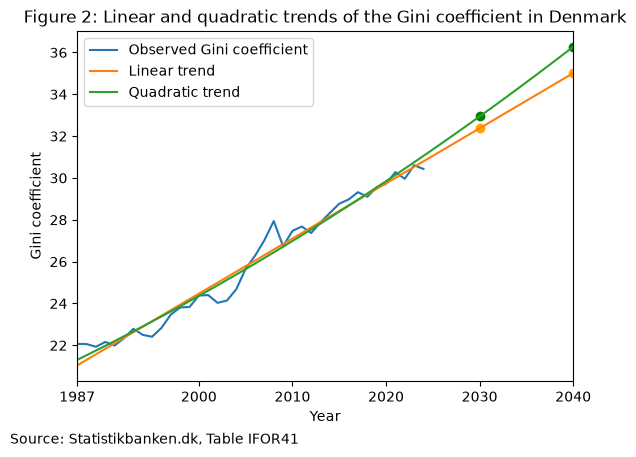

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize


# --------------------------------------------------
# 1. Prepare the data
# --------------------------------------------------

# Gini coefficient
y = df["INDHOLD"].to_numpy()

# t = number of years since 1987
t = df["TID"].to_numpy() - 1987


# --------------------------------------------------
# 2. Linear trend using scipy.optimize.minimize
# --------------------------------------------------

def objective_linear(beta):
    beta0, beta1 = beta

    y_hat = beta0 + beta1 * t

    return np.sum((y - y_hat) ** 2)


# Initial values
beta_start_linear = np.array([0, 0])

# Solve the minimization problem
result_linear = minimize(
    objective_linear,
    beta_start_linear
)

beta_linear = result_linear.x

print("Linear coefficients from minimize:")
print(beta_linear)


# --------------------------------------------------
# 3. Quadratic trend using scipy.optimize.minimize
# --------------------------------------------------

def objective_quadratic(beta):
    beta0, beta1, beta2 = beta

    y_hat = beta0 + beta1 * t + beta2 * t**2

    return np.sum((y - y_hat) ** 2)


# Initial values
beta_start_quadratic = np.array([0, 0, 0])

# Solve the minimization problem
result_quadratic = minimize(
    objective_quadratic,
    beta_start_quadratic
)

beta_quadratic = result_quadratic.x

print("\nQuadratic coefficients from minimize:")
print(beta_quadratic)


# --------------------------------------------------
# 4. Check the results using np.polyfit
# --------------------------------------------------

polyfit_linear = np.polyfit(t, y, 1)
polyfit_quadratic = np.polyfit(t, y, 2)

print("\nLinear coefficients:")
print("Minimize:", beta_linear)
print("Polyfit: ", polyfit_linear[::-1])

print("\nQuadratic coefficients:")
print("Minimize:", beta_quadratic)
print("Polyfit: ", polyfit_quadratic[::-1])


# --------------------------------------------------
# 5. Predictions for 2030 and 2040
# --------------------------------------------------

t_2030 = 2030 - 1987
t_2040 = 2040 - 1987


# Linear predictions
gini_linear_2030 = (
    beta_linear[0]
    + beta_linear[1] * t_2030
)

gini_linear_2040 = (
    beta_linear[0]
    + beta_linear[1] * t_2040
)


# Quadratic predictions
gini_quadratic_2030 = (
    beta_quadratic[0]
    + beta_quadratic[1] * t_2030
    + beta_quadratic[2] * t_2030**2
)

gini_quadratic_2040 = (
    beta_quadratic[0]
    + beta_quadratic[1] * t_2040
    + beta_quadratic[2] * t_2040**2
)


print("\nPredictions:")

print(
    "Linear prediction 2030:",
    round(gini_linear_2030, 2)
)

print(
    "Linear prediction 2040:",
    round(gini_linear_2040, 2)
)

print(
    "Quadratic prediction 2030:",
    round(gini_quadratic_2030, 2)
)

print(
    "Quadratic prediction 2040:",
    round(gini_quadratic_2040, 2)
)


# --------------------------------------------------
# 6. Create fitted and predicted values for the plot
# --------------------------------------------------

# Years from 1987 to 2040
years_plot = np.arange(1987, 2041)

# Convert years to t
t_plot = years_plot - 1987


# Linear trend
gini_linear = (
    beta_linear[0]
    + beta_linear[1] * t_plot
)


# Quadratic trend
gini_quadratic = (
    beta_quadratic[0]
    + beta_quadratic[1] * t_plot
    + beta_quadratic[2] * t_plot**2
)


# --------------------------------------------------
# 7. Plot historical data and predictions
# --------------------------------------------------

plt.plot(
    df["TID"],
    df["INDHOLD"],
    label="Observed Gini coefficient"
)

plt.plot(
    years_plot,
    gini_linear,
    label="Linear trend"
)

plt.plot(
    years_plot,
    gini_quadratic,
    label="Quadratic trend"
)


# Mark predictions for 2030 and 2040
plt.scatter(
    [2030, 2040],
    [gini_linear_2030, gini_linear_2040],
    color = "orange"
)

plt.scatter(
    [2030, 2040],
    [gini_quadratic_2030, gini_quadratic_2040],
    color = "green"
)


plt.xlabel("Year")
plt.ylabel("Gini coefficient")

plt.title(
    "Figure 2: Linear and quadratic trends of the Gini coefficient in Denmark"
)

plt.xticks(
    [1987, 2000, 2010, 2020, 2030, 2040]
)

plt.xlim(1987, 2040)

plt.legend()

plt.subplots_adjust(bottom=0.15)

plt.figtext(
    0.02,
    0.02,
    "Source: Statistikbanken.dk, Table IFOR41",
    ha="left"
)

plt.show()

## OPGAVE 1.3

In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO

url = "https://api.statbank.dk/v1/data"

query3 = {
   "table": "IFOR32",
   "format": "CSV",
   "variables": [
      {
         "code": "DECILGEN",
         "placement": "Stub",
         "values": [
            "10DC"
         ]
      },
      {
         "code": "KOMMUNEDK",
         "values": [
            "*"
         ]
      },
      {
         "code": "Tid",
         "values": [
            "*"
         ]
      }
   ]
}

response3 = requests.post(url, json=query3)

df3 = pd.read_csv(StringIO(response3.text),sep=";",decimal=",")

#Remove "Hele landet"

df3 = df3[df3["KOMMUNEDK"] != "Hele landet"].copy()

print(df3)


       DECILGEN  KOMMUNEDK   TID  INDHOLD
38    10. decil  København  1987   155794
39    10. decil  København  1988   163769
40    10. decil  København  1989   170177
41    10. decil  København  1990   177753
42    10. decil  København  1991   182779
...         ...        ...   ...      ...
3757  10. decil    Aalborg  2020   631707
3758  10. decil    Aalborg  2021   664032
3759  10. decil    Aalborg  2022   675088
3760  10. decil    Aalborg  2023   698292
3761  10. decil    Aalborg  2024   730961

[3724 rows x 4 columns]


## OPGAVE 2.1/2.2 (OPGAVE 2.1 is in the file life_cycle_model.py)

In [ ]:
import importlib.util
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Locate the life_cycle_model.py file
file_path = os.path.abspath("life_cycle_model.py")
if not os.path.exists(file_path):
    file_path = os.path.abspath(
        os.path.join("Data project", "life_cycle_model.py")
    )

# 2. Importing the module using importlib
spec = importlib.util.spec_from_file_location("life_cycle_model", file_path)
life_cycle_model = importlib.util.module_from_spec(spec)
spec.loader.exec_module(life_cycle_model)

# 3. Withdraw the function and run the simulation
simulate_lifecycle = life_cycle_model.simulate_lifecycle
sim = simulate_lifecycle(seed=23, N=50000)

print()

FileNotFoundError: [Errno 2] No such file or directory: '/Data project/life_cycle_model.py'

In [2]:
# Unpacking the simulated data
income = sim["income"]
employed = sim["employed"]
edu_idx = sim["edu_idx"]
p_e = sim["p_e"]
sigma_p = sim["sigma_p"]
lambda_p = sim["lambda_p"]

# =============================================================================
# PUNKT 1: Model Checks (Sanity Checks)
# =============================================================================
print("=== 1. SANITY CHECKS ===")

# Check Education shares: Simulated vs. theoretical
sim_p_e = [np.mean(edu_idx == i) for i in range(3)]
print(
    f"Simulating education distribution: Kort={sim_p_e[0]:.4f}, Mellem={sim_p_e[1]:.4f}, Lang={sim_p_e[2]:.4f}"
)
print(
    f"Theoretical p_e:                 Kort={p_e[0]:.4f}, Mellem={p_e[1]:.4f}, Lang={p_e[2]:.4f}"
)

# Check b: Ledighedsrate i steady-state (efter alle er færdiguddannede, fx ved t=25 / alder 43)
unemployment_rate_by_age = 1 - np.mean(employed, axis=0)
sim_ss_unemp = unemployment_rate_by_age[25]
theoretical_ss_unemp = sigma_p / (sigma_p + lambda_p)

print(
    f"Simulated unemployment rate (age 43): {sim_ss_unemp:.4f} ({sim_ss_unemp*100:.2f}%)"
)
print(
    f"Theoretical steady-state unemployment:   {theoretical_ss_unemp:.4f} ({theoretical_ss_unemp*100:.2f}%)\n"
)


# =============================================================================
# PUNKT 2: Plot mean and selected percentiles over the life cycle
# =============================================================================
ages = np.arange(18, 65)

# Beregn gennemsnit og percentiler over livscyklen
mean_inc = np.mean(income, axis=0)
p10 = np.percentile(income, 10, axis=0)
p25 = np.percentile(income, 25, axis=0)
p50 = np.percentile(income, 50, axis=0)
p75 = np.percentile(income, 75, axis=0)
p90 = np.percentile(income, 90, axis=0)

plt.figure(figsize=(10, 6))
plt.plot(ages, mean_inc, label="Mean", color="black", lw=2.5)
plt.plot(
    ages, p50, label="Median (P50)", color="navy", lw=2, linestyle="--"
)
plt.plot(ages, p90, label="P90", color="firebrick", lw=1.5, linestyle="-.")
plt.plot(ages, p75, label="P75", color="darkorange", lw=1.5, linestyle=":")
plt.plot(ages, p25, label="P25", color="green", lw=1.5, linestyle=":")
plt.plot(ages, p10, label="P10", color="gray", lw=1.5, linestyle="-.")

plt.title("Life Cycle Income: Mean and Selected Percentiles", fontsize=12)
plt.xlabel("Age")
plt.ylabel("Income ($y_{i,t}$)")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# =============================================================================
# PUNKT 3: Plot histograms of income distribution at ages 25, 35, 45, and 60
# =============================================================================
target_ages = [25, 35, 45, 60]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, age in enumerate(target_ages):
    t_idx = age - 18  # t_idx=0 svarer til alder 18
    inc_age = income[:, t_idx]

    axes[i].hist(
        inc_age,
        bins=60,
        density=True,
        color="skyblue",
        edgecolor="black",
        alpha=0.7,
    )
    axes[i].axvline(
        np.mean(inc_age),
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Mean: {np.mean(inc_age):.2f}",
    )
    axes[i].axvline(
        np.median(inc_age),
        color="navy",
        linestyle=":",
        linewidth=2,
        label=f"Median: {np.median(inc_age):.2f}",
    )

    axes[i].set_title(f"Income Distribution at Age {age}")
    axes[i].set_xlabel("Income")
    axes[i].set_ylabel("Density")
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

NameError: name 'sim' is not defined